In [2]:
import numpy as np
from copulas.univariate import GaussianKDE 
from copulas.bivariate import Clayton
from scipy.stats import t
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from collections import OrderedDict
import pandas as pd
import random
from scipy.stats import genpareto
from scipy.stats import expon,poisson,pareto
import pathlib
import numpy as np
import pingouin as pg

from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from tqdm import tqdm 

from Utils_StochasticSimulation import *

In [3]:
#########################################################################
#
#----------------------Joint Simulation Algorithm --------------
#
#########################################################################

def prodInd(j,deltaMatrix):
    vectDelta_j = list(deltaMatrix[:,j])
    vectDelta_j.remove(vectDelta_j[j])
    return np.prod(np.array(vectDelta_j)<0)
def ComputeWk(k,deltaMatrix):
    K = deltaMatrix.shape[0]
    Delta = list(deltaMatrix[k,:])
    Delta.remove(Delta[k])
    Ind = [prodInd(j,deltaMatrix)  for j in range(K) if j != k]
    WwoE = np.dot(np.array(Delta),np.array(Ind))
    return WwoE

def DeltaMatrix(i,DELTA,K):
    deltaMatrix_i = np.zeros((K,K))
    deltaMatrix_i[0,1:] = DELTA.iloc[i,:]
    deltaMatrix_i[:,0] = - deltaMatrix_i[0,:] 
    for k in range(1,K):
        for l in range(k,K):
            if k != l:
                deltaMatrix_i[k,l] = deltaMatrix_i[0,l] - deltaMatrix_i[0,k]
                deltaMatrix_i[l,k] = -deltaMatrix_i[k,l]

    return deltaMatrix_i

## The following function define our joint simulation algorithm 
def simulation(sample,M,replacing=False):
    N,K = sample.shape
    DELTA = pd.DataFrame(columns=np.arange(K-1),index=np.arange(N))
    newSample = pd.DataFrame(columns=np.arange(K),index=np.arange(M))
    for k in range(0,K-1):
        DELTA.iloc[:,k] = sample.iloc[:,0] - sample.iloc[:,k+1]
    if replacing :
        Msample = DELTA.iloc[np.random.choice(list(np.arange(N)),M),:]
    else :
        Msample = DELTA.iloc[random.sample(list(np.arange(N)),M),:]
    E = expon.rvs(size=M)

    for m in range(M):
        deltaMatrix_m = DeltaMatrix(m,Msample,K)
        for k in range(K):
            newSample.iloc[m,k] = E[m] +  ComputeWk(k,deltaMatrix_m)
    return newSample



#########################################################################
#
#----------------------Conditional Simulation Algorithm --------------
#
#########################################################################


# Avec correction du 15/02
def CondSimulationExtremes(k,w,DeltaMatrix,ExcessStand,M):
    checkStep = []
    nDELTA,K = DeltaMatrix.shape
    Wk = np.zeros(M)
    if k != 0:
        w_wo_k = np.concatenate([w[0:k],w[k+1:]])
        kloc = 0
        idxDelta = k-1
    else:
        w_wo_k = w[1:]
        kloc =  (K+1) - 1
        idxDelta = k
    istar = np.argmax(w_wo_k) 
    istarAll = list(w).index(w_wo_k[istar])
    max_wo_k = np.max(w_wo_k)
    if max_wo_k > 0:
        
        if (istarAll == kloc): 
            checkStep.append(0)
        
            Tpos = set(list(np.arange(nDELTA)[np.delete(ExcessStand,k,1)[:,kloc]>0]))
            Tmax = set(list(np.arange(nDELTA)[np.argmax(np.delete(ExcessStand,k,1),axis=1)==kloc]))
            T = list(Tpos&Tmax)
            DELTAW1max = DeltaMatrix.iloc[T,:]
            Npos = DELTAW1max.shape[0]
            deltaSim = DELTAW1max.iloc[np.random.choice(list(np.arange(Npos)),M),idxDelta].values
            Wk = w[kloc] - deltaSim
        else :
            checkStep.append(1)
            
            for i in range(M):

                delta_star = w[kloc] - w_wo_k[istar]
                cond = True
                while cond:
                    delta_k = DeltaMatrix.iloc[np.random.choice(list(np.arange(nDELTA)),1),idxDelta].values[0]
                    u = stats.uniform.rvs()
                    cond = u > (np.exp(delta_k)*(delta_star>delta_k) + np.exp(delta_star)*(delta_star<delta_k))

                Wk[i] = w[kloc] - delta_k
    else:
        
        for i in tqdm(range(M)):
            checkStep.append(2)
            cond = True
            while cond:
                delta_k = DeltaMatrix.iloc[np.random.choice(list(np.arange(nDELTA)),1),idxDelta].values[0]
                u = stats.uniform.rvs()
                cond = u > (np.exp(delta_k)*(delta_k<w[kloc]))
            Wk[i] = w[kloc] - delta_k
    return Wk,checkStep

# I. Import Data 

In [6]:
def importData_txt(fileprice,filedates,name):
    path = r"Data"
    
    prices = open(pathlib.PurePath(path, fileprice + '.txt'),'r')
    prices = prices.readlines()
    dates = open(pathlib.PurePath(path, filedates + '.txt'),'r')
    dates = dates.readlines()
    
    
    # Créer un dataframe à partir des lignes du fichier
    data = {name: [float(line.strip()) for line in prices]}
    df = pd.DataFrame(data)
    date = [line.strip() for line in dates]

    df.index = date
    return df



In [12]:
dfBIT = importData_txt('BIT_Price','BIT_Date','BIT')
dfBNB = importData_txt('BNB_Price','BNB_Date','BNB')
dfDOG = importData_txt('DOG_Price','DOG_Date','DOG')

In [13]:
datesBIT = set(dfBIT.index)
datesBNB = set(dfBNB.index)
datesDOG = set(dfDOG.index)

intersection_dates = list(datesBIT.intersection(datesBNB,datesDOG))
intersection_dates = pd.to_datetime(intersection_dates)
intersection_dates = intersection_dates.sort_values()[::-1]
intersection_dates = intersection_dates.strftime('%Y-%m-%d')


In [14]:
dfBIT = dfBIT.loc[intersection_dates,:]
dfBNB = dfBNB.loc[intersection_dates,:]
dfDOG = dfDOG.loc[intersection_dates,:]

In [15]:
Data = pd.DataFrame(columns=['BIT','BNB','DOG'])
Data.BIT = dfBIT.BIT
Data.BNB = dfBNB.BNB
Data.DOG = dfDOG.DOG

Data.index = intersection_dates

In [16]:
DataReturns  = pd.DataFrame(columns=['BIT','BNB','DOG'])

DataReturns.BIT = -(Data.BIT.values[:-1]-Data.BIT.values[1:])/Data.BIT.values[1:] 
DataReturns.BNB = -(Data.BNB.values[:-1]-Data.BNB.values[1:])/Data.BNB.values[1:] 
DataReturns.DOG = -(Data.DOG.values[:-1]-Data.DOG.values[1:])/Data.DOG.values[1:] 

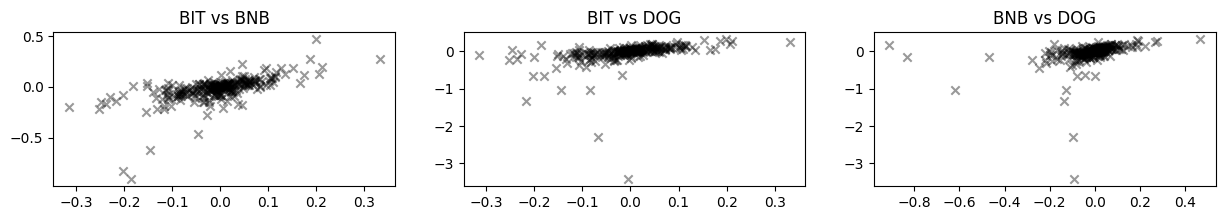

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 2))
ax[0].scatter(DataReturns.BIT.values,DataReturns.BNB,c='k',alpha=0.4,marker='x')
ax[0].set_title('BIT vs BNB')

ax[1].scatter(DataReturns.BIT.values,DataReturns.DOG,c='k',alpha=0.4,marker='x')
ax[1].set_title('BIT vs DOG')


ax[2].scatter(DataReturns.BNB.values,DataReturns.DOG,c='k',alpha=0.4,marker='x')
ax[2].set_title('BNB vs DOG')


plt.show()

# II. Marginal Fit 

In [18]:
nuBIT,lBIT,sBIT = t.fit(DataReturns.BIT.values)
nuBNB,lBNB,sBNB = t.fit(DataReturns.BNB.values)
nuDOG,lDOG,sDOG = t.fit(DataReturns.DOG.values)


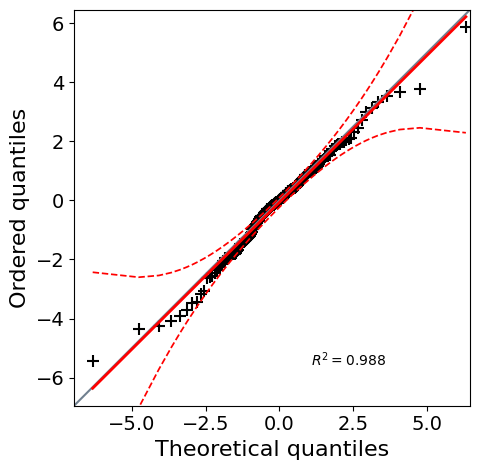

In [19]:

ax = pg.qqplot((DataReturns.BIT.values-lBIT)/sBIT, dist="t", sparams=(nuBIT,), confidence=.95,marker='+', color='k',s=80)
ax.set_xlabel('Theoretical quantiles',fontsize=16)
ax.set_ylabel('Ordered quantiles',fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)
plt.tight_layout()


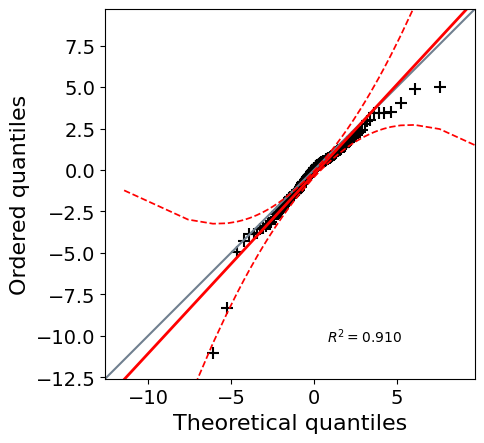

In [20]:
ax = pg.qqplot((DataReturns.BNB.values-lBNB)/sBNB, dist="t",sparams=(nuBNB,), confidence=.95,marker='+', color='k',s=80)
ax.set_xlabel('Theoretical quantiles',fontsize=16)
ax.set_ylabel('Ordered quantiles',fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)


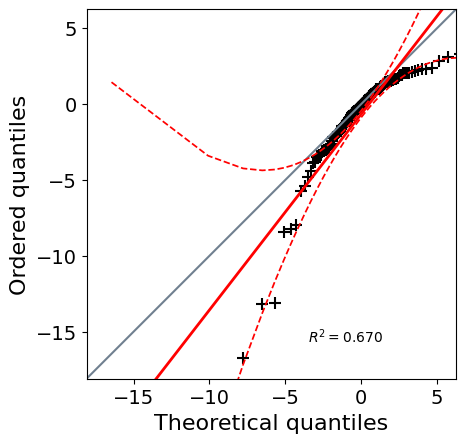

In [21]:
ax = pg.qqplot((DataReturns.DOG.values-lDOG)/sDOG, dist="t", sparams=(nuDOG,), confidence=.95,marker='+', color='k',s=80)

ax.set_xlabel('Theoretical quantiles',fontsize=16)
ax.set_ylabel('Ordered quantiles',fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)


# III. Data Processing
## 1. Transformation to uniform Scale

In [22]:
uBIT = t.cdf(DataReturns.BIT.values,loc=lBIT,scale=sBIT,df=nuBIT)
uBNB = t.cdf(DataReturns.BNB.values,loc=lBNB,scale=sBNB,df=nuBNB)
uDOG = t.cdf(DataReturns.DOG.values,loc=lDOG,scale=sDOG,df=nuDOG)


## 2. Transformation to Exponential Scale

In [23]:
e_BIT = expon.ppf(uBIT)
e_BNB = expon.ppf(uBNB)
e_DOG = expon.ppf(uDOG)
dfStand = pd.DataFrame(np.concatenate([e_BIT.reshape(-1,1),e_BNB.reshape(-1,1),e_DOG.reshape(-1,1)],axis=1))


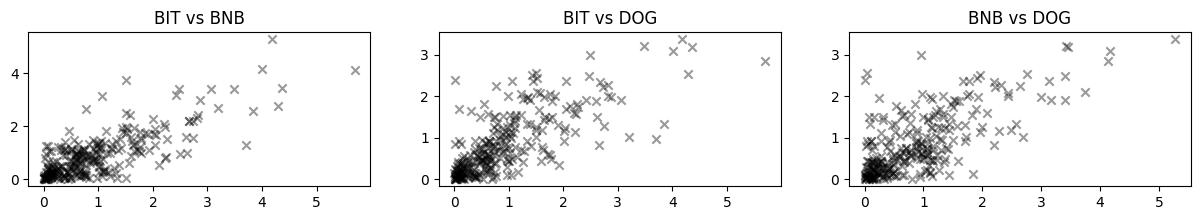

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(15, 2))
ax[0].scatter(e_BIT,e_BNB,alpha=0.4,c='k',marker='x')
ax[0].set_title('BIT vs BNB')


ax[1].scatter(e_BIT,e_DOG,alpha=0.4,c='k',marker='x')
ax[1].set_title('BIT vs DOG')



ax[2].scatter(e_BNB,e_DOG,alpha=0.4,c='k',marker='x')
ax[2].set_title('BNB vs DOG')

plt.show()

## 3. Defining Excesses



In [25]:
alphaU = 0.83
t_BIT = np.quantile(e_BIT,alphaU)
t_BNB = np.quantile(e_BNB,alphaU)
t_DOG = np.quantile(e_DOG,alphaU)
n = len(e_BIT)

In [26]:
TX0 = (np.arange(n)[dfStand.iloc[:,0]>t_BIT]).reshape(-1,)
TY0 = (np.arange(n)[dfStand.iloc[:,1]>t_BNB]).reshape(-1,)
TZ0 = (np.arange(n)[dfStand.iloc[:,2]>t_DOG]).reshape(-1,)

T0 = np.concatenate([TX0,TY0,TZ0])


T0 = np.array(list(OrderedDict.fromkeys(list(T0))),dtype=int)
ExcessStand = dfStand.iloc[T0,:]
ExcessStand.iloc[:,0] = ExcessStand.iloc[:,0] - t_BIT
ExcessStand.iloc[:,1] = ExcessStand.iloc[:,1] - t_BNB
ExcessStand.iloc[:,2] = ExcessStand.iloc[:,2] - t_DOG

ExcessStand = ExcessStand.values

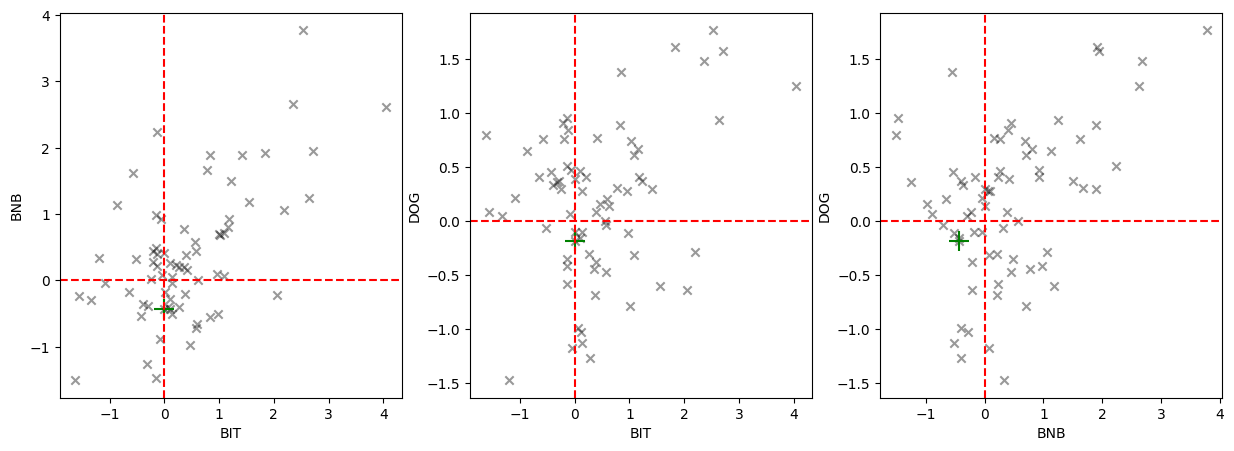

In [27]:
I = 20
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].scatter(ExcessStand[:,0],ExcessStand[:,1],alpha=0.4,marker='x',c='k')
ax[0].scatter(ExcessStand[I,0],ExcessStand[I,1],marker='+',c='green',s=200)
ax[0].axvline(0,linestyle='--',color='r')
ax[0].axhline(0,linestyle='--',color='r')
ax[0].set_xlabel('BIT')
ax[0].set_ylabel('BNB')

ax[1].scatter(ExcessStand[:,0],ExcessStand[:,2],alpha=0.4,marker='x',c='k')
ax[1].scatter(ExcessStand[I,0],ExcessStand[I,2],marker='+',c='green',s=200)
ax[1].axvline(0,linestyle='--',color='r')
ax[1].axhline(0,linestyle='--',color='r')
ax[1].set_xlabel('BIT')
ax[1].set_ylabel('DOG')




ax[2].scatter(ExcessStand[:,1],ExcessStand[:,2],alpha=0.4,marker='x',c='k')
ax[2].scatter(ExcessStand[I,1],ExcessStand[I,2],marker='+',c='green',s=200)
ax[2].axvline(0,linestyle='--',color='r')
ax[2].axhline(0,linestyle='--',color='r')
ax[2].set_xlabel('BNB')
ax[2].set_ylabel('DOG')



plt.show()

# IV. Joint Simulation
## 1. Excesses in Exponential Scale 

In [28]:
M = 10000
Simd4 = simulation(pd.DataFrame(ExcessStand),M,True)
ExcessSim = Simd4.values


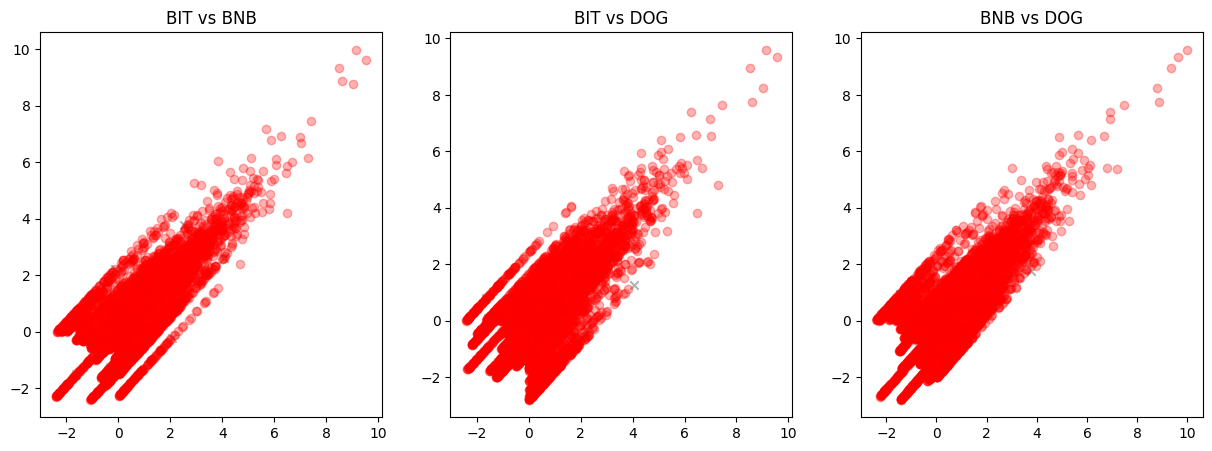

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].scatter(ExcessStand[:,0],ExcessStand[:,1],c='k',marker='x',alpha=0.3)
ax[0].scatter(ExcessSim[:,0],ExcessSim[:,1],c='r',marker='o',alpha=0.3)
ax[0].set_title('BIT vs BNB')

ax[1].scatter(ExcessStand[:,0],ExcessStand[:,2],c='k',marker='x',alpha=0.3)
ax[1].scatter(ExcessSim[:,0],ExcessSim[:,2],c='r',marker='o',alpha=0.3)
ax[1].set_title('BIT vs DOG')


ax[2].scatter(ExcessStand[:,1],ExcessStand[:,2],c='k',marker='x',alpha=0.3)
ax[2].scatter(ExcessSim[:,1],ExcessSim[:,2],c='r',marker='o',alpha=0.3)
ax[2].set_title('BNB vs DOG')




plt.show()

In [30]:
alphaVect = np.linspace(0.01,0.99,100)


ExcessSimPos = ExcessSim[ExcessSim[:,0]>0,0] 
ExcessStandPos = ExcessStand[ExcessStand[:,0]>0,0]

alphaN = np.array(len(ExcessSimPos)*alphaVect,dtype=int)
alphaM = np.array(len(ExcessStandPos)*alphaVect,dtype=int)
rSimPos = t.ppf(expon.cdf(np.array(ExcessSimPos+t_BIT,dtype=float)),loc=lBIT,scale=sBIT,df=nuBIT)
rPos = t.ppf(expon.cdf(np.array(ExcessStandPos+t_BIT,dtype=float)),loc=lBIT,scale=sBIT,df=nuBIT)


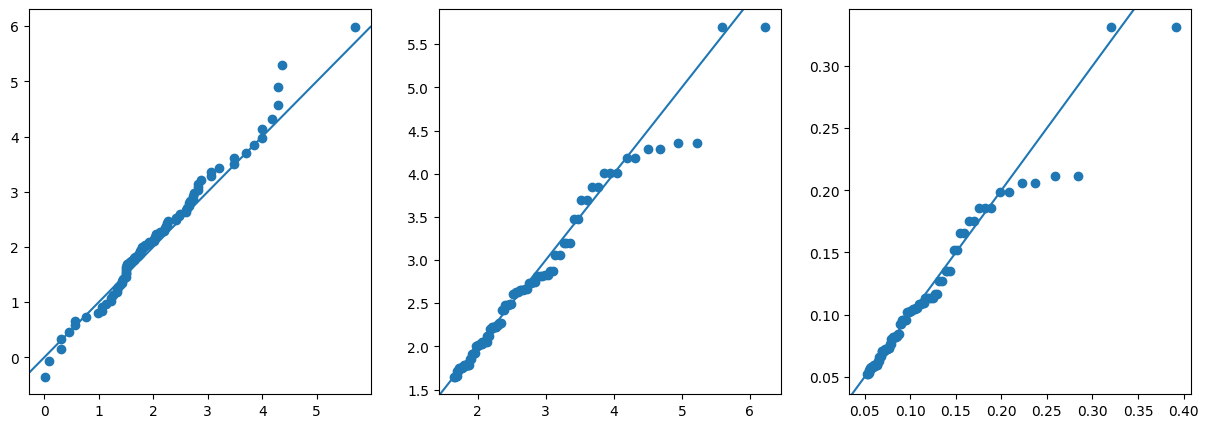

In [31]:
n = ExcessStand.shape[0]
alphaVect = np.linspace(0.01,0.99,100)
alphaN = np.array(n*alphaVect,dtype=int)
alphaM = np.array(M*alphaVect,dtype=int)



fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].scatter(np.sort(ExcessStand[:,0]+t_BIT)[alphaN],(np.sort(ExcessSim[:,0]+t_BIT))[alphaM])
ax[0].axline((0, 0), slope=1)

alphaN = np.array(len(ExcessSimPos)*alphaVect,dtype=int)
alphaM = np.array(len(ExcessStandPos)*alphaVect,dtype=int)

ax[1].scatter(np.sort(ExcessSimPos+t_BIT)[alphaN],(np.sort(ExcessStandPos+t_BIT))[alphaM])
ax[1].axline((2, 2), slope=1)


rSimPos = t.ppf(expon.cdf(np.array(ExcessSimPos+t_BIT,dtype=float)),loc=lBIT,scale=sBIT,df=nuBIT)
rhsbcPos = t.ppf(expon.cdf(np.array(ExcessStandPos+t_BIT,dtype=float)),loc=lBIT,scale=sBIT,df=nuBIT)


ax[2].scatter(np.sort(rSimPos)[alphaN],(np.sort(rhsbcPos))[alphaM])
ax[2].axline((0.05, 0.05), slope=1)


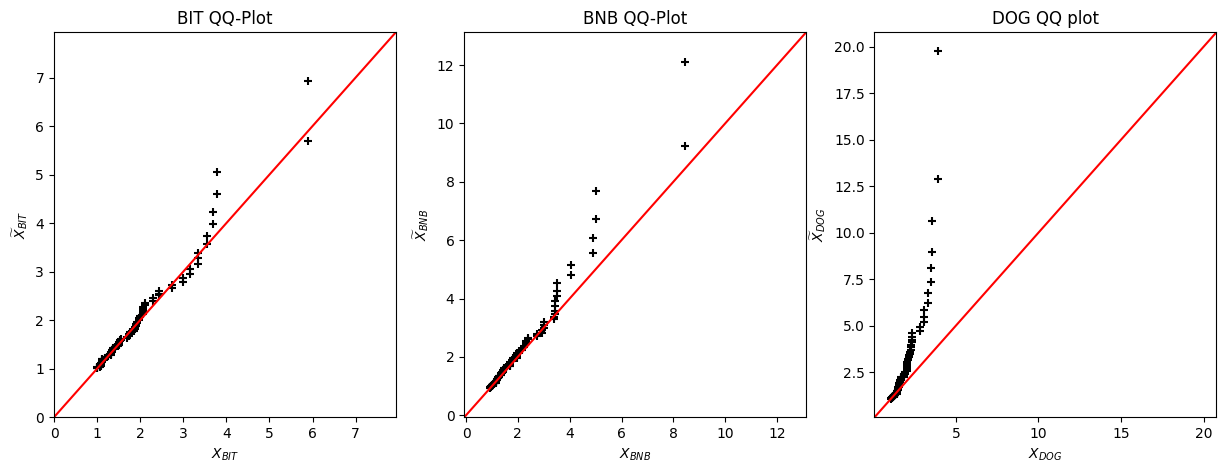

In [33]:
#################################################################################################################
#
#--------------------------------------- BIT QQPlot simu vs Observed --------------------------------------------
#
##################################################################################################################


fig, ax = plt.subplots(1, 3, figsize=(15,5))

ExcessSimPos = ExcessSim[ExcessSim[:,0]>0,0] 
ExcessStandPos = ExcessStand[ExcessStand[:,0]>0,0]

alphaN = np.array(len(ExcessSimPos)*alphaVect,dtype=int)
alphaM = np.array(len(ExcessStandPos)*alphaVect,dtype=int)


# rSimPos = t.ppf(expon.cdf(np.array(ExcessSimPos+t_HSBC,dtype=float)),loc=lHSBC,scale=sHSBC,df=nuHSBC)
# rPos = t.ppf(expon.cdf(np.array(ExcessStandPos+t_HSBC,dtype=float)),loc=lHSBC,scale=sHSBC,df=nuHSBC)

rSimPos = t.ppf(expon.cdf(np.array(ExcessSimPos+t_BIT,dtype=float)),df=nuBIT)
rPos = t.ppf(expon.cdf(np.array(ExcessStandPos+t_BIT,dtype=float)),df=nuBIT)


xmin = (np.sort(rPos))[alphaM].min()-1
xmax = (np.sort(rPos))[alphaM].max()+1

ymin = np.sort(rSimPos)[alphaN].min()-1
ymax = np.sort(rSimPos)[alphaN].max()+1

ax[0].scatter((np.sort(rPos))[alphaM],np.sort(rSimPos)[alphaN],marker='+',color='k')
ax[0].set_xlim(min(xmin,ymin), max(xmax,ymax))
ax[0].set_ylim(min(xmin,ymin), max(xmax,ymax))
ax[0].set_xlabel('$X_{BIT}$')
ax[0].set_ylabel(r'$\widetilde{X}_{BIT}$')

ax[0].axline((0.05, 0.05), slope=1,c='r')
ax[0].set_title('BIT QQ-Plot')


#################################################################################################################
#
#--------------------------------------- BNB QQPlot simu vs Observed --------------------------------------------
#
##################################################################################################################



ExcessSimPos = ExcessSim[ExcessSim[:,1]>0,1] 
ExcessStandPos = ExcessStand[ExcessStand[:,1]>0,1]

alphaN = np.array(len(ExcessSimPos)*alphaVect,dtype=int)
alphaM = np.array(len(ExcessStandPos)*alphaVect,dtype=int)


# rSimPos = t.ppf(expon.cdf(np.array(ExcessSimPos+t_LL,dtype=float)),loc=lLL,scale=sLL,df=nuLL)
# rPos = t.ppf(expon.cdf(np.array(ExcessStandPos+t_LL,dtype=float)),loc=lLL,scale=sLL,df=nuLL)

rSimPos = t.ppf(expon.cdf(np.array(ExcessSimPos+t_BNB,dtype=float)),df=nuBNB)
rPos = t.ppf(expon.cdf(np.array(ExcessStandPos+t_BNB,dtype=float)),df=nuBNB)


xmin = (np.sort(rPos))[alphaM].min()-1
xmax = (np.sort(rPos))[alphaM].max()+1

ymin = np.sort(rSimPos)[alphaN].min()-1
ymax = np.sort(rSimPos)[alphaN].max()+1

ax[1].scatter((np.sort(rPos))[alphaM],np.sort(rSimPos)[alphaN],marker='+',color='k')
ax[1].set_xlim(min(xmin,ymin), max(xmax,ymax))
ax[1].set_ylim(min(xmin,ymin), max(xmax,ymax))
ax[1].set_xlabel('$X_{BNB}$')
ax[1].set_ylabel(r'$\widetilde{X}_{BNB}$')

ax[1].axline((0.05, 0.05), slope=1,c='r')
ax[1].set_title('BNB QQ-Plot')

#################################################################################################################
#
#--------------------------------------- DOG QQPlot simu vs Observed --------------------------------------------
#
##################################################################################################################



ExcessSimPos = ExcessSim[ExcessSim[:,2]>0,2] 
ExcessStandPos = ExcessStand[ExcessStand[:,2]>0,2]

alphaN = np.array(len(ExcessSimPos)*alphaVect,dtype=int)
alphaM = np.array(len(ExcessStandPos)*alphaVect,dtype=int)


# rSimPos = t.ppf(expon.cdf(np.array(ExcessSimPos+t_RBS,dtype=float)),loc=lRBS,scale=sRBS,df=nuRBS)
# rPos = t.ppf(expon.cdf(np.array(ExcessStandPos+t_RBS,dtype=float)),loc=lRBS,scale=sRBS,df=nuRBS)

rSimPos = t.ppf(expon.cdf(np.array(ExcessSimPos+t_DOG,dtype=float)),df=nuDOG)
rPos = t.ppf(expon.cdf(np.array(ExcessStandPos+t_DOG,dtype=float)),df=nuDOG)

xmin = (np.sort(rPos))[alphaM].min()-1
xmax = (np.sort(rPos))[alphaM].max()+1

ymin = np.sort(rSimPos)[alphaN].min()-1
ymax = np.sort(rSimPos)[alphaN].max()+1

ax[2].scatter((np.sort(rPos))[alphaM],np.sort(rSimPos)[alphaN],marker='+',color='k')
ax[2].axline((0.05, 0.05), slope=1,c='r')
ax[2].set_xlim(min(xmin,ymin), max(xmax,ymax))
ax[2].set_xlabel('$X_{DOG}$')
ax[2].set_ylabel(r'$\widetilde{X}_{DOG}$')
ax[2].set_ylim(min(xmin,ymin), max(xmax,ymax))


ax[2].set_title('DOG QQ plot')

plt.show()



## 2. Backward Tranformation to original scale 

In [34]:
eSim_BIT = ExcessSim[:,0] + t_BIT
eSim_BNB = ExcessSim[:,1] + t_BNB
eSim_DOG = ExcessSim[:,2] + t_DOG


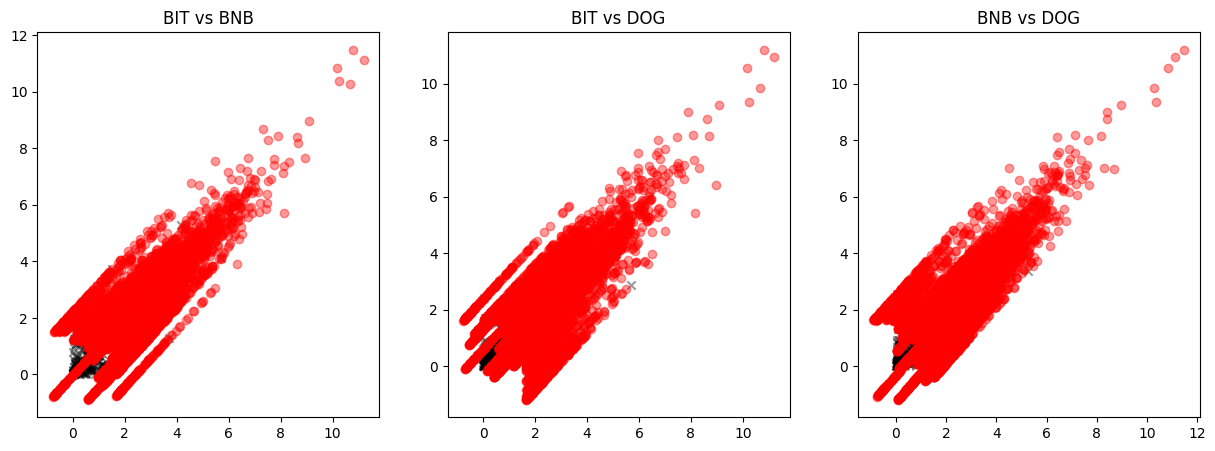

In [35]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].scatter(e_BIT,e_BNB,alpha=0.4,c='k',marker='x')
ax[0].scatter(eSim_BIT,eSim_BNB,alpha=0.4,c='r',marker='o')
ax[0].set_title('BIT vs BNB')


ax[1].scatter(e_BIT,e_DOG,alpha=0.4,c='k',marker='x')
ax[1].scatter(eSim_BIT,eSim_DOG,alpha=0.4,c='r',marker='o')
ax[1].set_title('BIT vs DOG')



ax[2].scatter(e_BNB,e_DOG,alpha=0.4,c='k',marker='x')
ax[2].scatter(eSim_BNB,eSim_DOG,alpha=0.4,c='r',marker='o')
ax[2].set_title('BNB vs DOG')




plt.show()

In [36]:
uSim_BIT = expon.cdf(np.array(eSim_BIT,dtype=float))
uSim_BNB = expon.cdf(np.array(eSim_BNB,dtype=float))
uSim_DOG = expon.cdf(np.array(eSim_DOG,dtype=float))


In [37]:
rSim_BIT = t.ppf(uSim_BIT,loc=lBIT,scale=sBIT,df=nuBIT)
rSim_BNB = t.ppf(uSim_BNB,loc=lBNB,scale=sBNB,df=nuBNB)
rSim_DOG = t.ppf(uSim_DOG,loc=lDOG,scale=sDOG,df=nuDOG)


In [38]:
dfSim = pd.DataFrame(columns=['BIT','BNB','DOG'])

dfSim.BIT = rSim_BIT
dfSim.BNB = rSim_BNB
dfSim.DOG = rSim_DOG


---
# A. Tail risk metrics estimation with joint simulation algorithm 

---

In [39]:
alphaVaR = 0.9975
VaRBIT = t.ppf(alphaVaR,df=nuBIT,loc=lBIT,scale=sBIT)
VaRBNB = t.ppf(alphaVaR,df=nuBNB,loc=lBNB,scale=sBNB)
VaRDOG = t.ppf(alphaVaR,df=nuDOG,loc=lDOG,scale=sDOG)

## 1. One shoot estimation
### 1. ES Estimation 

In [40]:
ES_Emp_BIT = np.mean(DataReturns.BIT.values[DataReturns.BIT.values>VaRBIT])
ES_Emp_BNB = np.mean(DataReturns.BNB.values[DataReturns.BNB.values>VaRBNB])
ES_Emp_DOG = np.mean(DataReturns.DOG.values[DataReturns.DOG.values>VaRDOG])

ES_Simu_BIT = np.mean(dfSim.BIT.values[dfSim.BIT.values>VaRBIT])
ES_Simu_BNB = np.mean(dfSim.BNB.values[dfSim.BNB.values>VaRBNB])
ES_Simu_DOG = np.mean(dfSim.DOG.values[dfSim.DOG.values>VaRDOG])

ES_t_BIT = lBIT + sBIT*((nuBIT+t.ppf(alphaVaR,df=nuBIT)**2)/((nuBIT-1)*(1-alphaVaR)) * t.pdf(t.ppf(alphaVaR,df= nuBIT),df=nuBIT))
ES_t_BNB = lBNB+ sBNB*((nuBNB+t.ppf(alphaVaR,df=nuBNB)**2)/((nuBNB-1)*(1-alphaVaR)) * t.pdf(t.ppf(alphaVaR,df= nuBNB),df=nuBNB))
ES_t_DOG = lDOG + sDOG*((nuDOG+t.ppf(alphaVaR,df=nuDOG)**2)/((nuDOG-1)*(1-alphaVaR)) * t.pdf(t.ppf(alphaVaR,df= nuDOG),df=nuDOG))

/opt/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### 2. DCTE Estimation

In [41]:
n = len(DataReturns.BIT.values)
TBIT = set(np.arange(n)[DataReturns.BIT.values>VaRBIT])
TBNB = set(np.arange(n)[DataReturns.BNB.values>VaRBNB])
TDOG = set(np.arange(n)[DataReturns.DOG.values>VaRDOG])
T_dcte = list(TBIT&TBNB&TDOG)


In [42]:
n = len(DataReturns.BIT.values)
TBIT = set(np.arange(n)[DataReturns.BIT.values>VaRBIT])
TBNB = set(np.arange(n)[DataReturns.BNB.values>VaRBNB])
TDOG = set(np.arange(n)[DataReturns.DOG.values>VaRDOG])
T_dcte = list(TBIT&TBNB&TDOG)

DE_BIT = np.mean(DataReturns.BIT.values[T_dcte])
DE_BNB = np.mean(DataReturns.BNB.values[T_dcte])
DE_DOG = np.mean(DataReturns.DOG.values[T_dcte])
DE_BIT,DE_BNB,DE_DOG


/opt/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(nan, nan, nan)

In [43]:
nSimu = len(dfSim.BIT.values)
TBIT = set(np.arange(nSimu)[dfSim.BIT.values>VaRBIT])
TBNB = set(np.arange(nSimu)[dfSim.BNB.values>VaRBNB])
TDOG = set(np.arange(nSimu)[dfSim.DOG.values>VaRDOG])
T_dcte_simu = list(TBIT&TBNB&TDOG)

DE_Simu_BIT = np.mean(dfSim.BIT.values[T_dcte_simu])
DE_Simu_BNB = np.mean(dfSim.BNB.values[T_dcte_simu])
DE_Simu_DOG = np.mean(dfSim.DOG.values[T_dcte_simu])

DE_Simu_BIT,DE_Simu_BNB,DE_Simu_DOG


(0.6403719496406215, 1.6649219483694537, 4.19453388097593)

### 3. MES Estimation 

In [44]:
n = len(DataReturns.BIT.values)
TBIT = set(np.arange(n)[DataReturns.BIT.values>VaRBIT])
TBNB = set(np.arange(n)[DataReturns.BNB.values>VaRBNB])
TDOG = set(np.arange(n)[DataReturns.DOG.values>VaRDOG])
T_MES_BIT = list(TBNB&TDOG)
T_MES_BNB = list(TBIT&TDOG)
T_MES_DOG = list(TBNB&TBIT)


MES_BIT = np.mean(DataReturns.BIT.values[T_MES_BIT])
MES_BNB = np.mean(DataReturns.BNB.values[T_MES_BNB])
MES_DOG = np.mean(DataReturns.DOG.values[T_MES_DOG])
MES_BIT,MES_BNB,MES_DOG


/opt/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(nan, nan, nan)

In [45]:
nSimu = len(dfSim.BIT.values)
TBIT = set(np.arange(nSimu)[dfSim.BIT.values>VaRBIT])
TBNB = set(np.arange(nSimu)[dfSim.BNB.values>VaRBNB])
TDOG = set(np.arange(nSimu)[dfSim.DOG.values>VaRDOG])
T_MES_BIT_simu = list(TBNB&TDOG)
T_MES_BNB_simu = list(TBIT&TDOG)
T_MES_DOG_simu = list(TBNB&TBIT)

MES_Simu_BIT = np.mean(dfSim.BIT.values[T_MES_BIT_simu])
MES_Simu_BNB = np.mean(dfSim.BNB.values[T_MES_BNB_simu])
MES_Simu_DOG = np.mean(dfSim.DOG.values[T_MES_DOG_simu])

MES_Simu_BIT,MES_Simu_BNB,MES_Simu_DOG



(0.5934361155449416, 1.5165867915973752, 3.6251877815193123)

In [46]:
dfTRM = pd.DataFrame(columns=['Max','VaR t','ES Emp','ES t','ES Simu','DCTE Emp','DCTE Simu','MES Emp','MES Simu'],index=['BIT','BNB','DOG'])
dfTRM['Max'] = [DataReturns.BIT.values.max(),DataReturns.BNB.values.max(),DataReturns.DOG.values.max()]

dfTRM['VaR t'] = [VaRBIT,VaRBNB,VaRDOG]
dfTRM['ES Emp'] = [ES_Emp_BIT,ES_Emp_BNB,ES_Emp_DOG]
dfTRM['ES t'] = [ES_t_BIT,ES_t_BNB,ES_t_DOG]
dfTRM['ES Simu'] = [ES_Simu_BIT,ES_Simu_BNB,ES_Simu_DOG]
dfTRM['DCTE Emp'] = [DE_BIT,DE_BNB,DE_DOG]
dfTRM['DCTE Simu'] = [DE_Simu_BIT,DE_Simu_BNB,DE_Simu_DOG]
dfTRM['MES Emp'] = [MES_BIT,MES_BNB,MES_DOG]
dfTRM['MES Simu'] = [MES_Simu_BIT,MES_Simu_BNB,MES_Simu_DOG]
dfTRM

,Max,VaR t,ES Emp,ES t,ES Simu,DCTE Emp,DCTE Simu,MES Emp,MES Simu
BIT,0.331541,0.363543,NaN,0.523140,0.522438,NaN,0.640372,NaN,0.593436
BNB,0.468467,0.653601,NaN,1.208000,1.378297,NaN,1.664922,NaN,1.516587
DOG,0.327056,1.378843,NaN,3.028391,3.359011,NaN,4.194534,NaN,3.625188


## 2. TRM estimation through multiple runs 

In [47]:
VaRBIT = t.ppf(alphaVaR,df=nuBIT,loc=lBIT,scale=sBIT)
VaRBNB = t.ppf(alphaVaR,df=nuBNB,loc=lBNB,scale=sBNB)
VaRDOG = t.ppf(alphaVaR,df=nuDOG,loc=lDOG,scale=sDOG)

def getEstimateTRMK3s(VaR,df):
    n,K = df.shape
    T = {}
    for k in range(K):
        T[str(k)] = set(np.arange(n)[df.iloc[:,k]>VaR[k]])
    
    T_dcte = list(T[str(0)]&T[str(1)]&T[str(2)])
    T_mes = [list(T[str(1)]&T[str(2)]),list(T[str(0)]&T[str(2)]),list(T[str(0)]&T[str(1)])]
    
    ES,MES,DCTE = np.zeros(K),np.zeros(K),np.zeros(K)
    
    for i in range(K):
        ES[i] = np.mean(df.iloc[:,i].values[df.iloc[:,i].values>VaR[i]])
        MES[i] = np.mean(df.iloc[T_mes[i],i])
        DCTE[i] = np.mean(df.iloc[T_dcte,i])

    return ES,MES,DCTE
    
Q = 1000
VaRt = [VaRBIT,VaRBNB,VaRDOG]
ES_Emp,MES_Emp,DCTE_Emp = getEstimateTRMK3s(VaRt,DataReturns)

dfTRMS = pd.DataFrame(columns =['ES Simu','MES Simu','DCTE Simu','Stock'],index=np.arange(Q*3))




/opt/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [48]:
for i in tqdm(range(Q)):
    ExcessSim = simulation(pd.DataFrame(ExcessStand),M,True).values


    eSim_BIT = ExcessSim[:,0] + t_BIT
    eSim_BNB = ExcessSim[:,1] + t_BNB
    eSim_DOG = ExcessSim[:,2] + t_DOG


    uSim_BIT = expon.cdf(np.array(eSim_BIT,dtype=float))
    uSim_BNB = expon.cdf(np.array(eSim_BNB,dtype=float))
    uSim_DOG = expon.cdf(np.array(eSim_DOG,dtype=float))

    rSim_BIT = t.ppf(uSim_BIT,loc=lBIT,scale=sBIT,df=nuBIT)
    rSim_BNB = t.ppf(uSim_BNB,loc=lBNB,scale=sBNB,df=nuBNB)
    rSim_DOG = t.ppf(uSim_DOG,loc=lDOG,scale=sDOG,df=nuDOG)


    dfSim = pd.DataFrame(columns=['BIT','BNB','DOG'])

    dfSim.BIT = rSim_BIT
    dfSim.BNB = rSim_BNB
    dfSim.DOG = rSim_DOG


    getEstimateTRMK3s(VaRt,dfSim)
    ES_Simu,MES_Simu,DCTE_Simu = getEstimateTRMK3s(VaRt,dfSim)

    dfTRMS.iloc[i*3:(i+1)*3,0] = ES_Simu 
    dfTRMS.iloc[i*3:(i+1)*3,1] = MES_Simu 
    dfTRMS.iloc[i*3:(i+1)*3,2] = DCTE_Simu 
    dfTRMS.iloc[i*3:(i+1)*3,3] = ['BIT','BNB','DOG'] 

100%|██████████| 1000/1000 [20:52<00:00,  1.25s/it]


In [49]:
display(dfTRMS.groupby(['Stock']).mean()),display(dfTRMS.groupby(['Stock']).std())

,ES Simu,MES Simu,DCTE Simu
Stock,,,
BIT,0.522042,0.58608,0.624925
BNB,1.200954,1.324894,1.472182
DOG,3.012863,3.119003,3.772809


,ES Simu,MES Simu,DCTE Simu
Stock,,,
BIT,0.024473,0.041703,0.044805
BNB,0.146497,0.214362,0.247213
DOG,0.612688,0.738590,0.968572


(None, None)